### Question 1
Download a sample credit card fraud dataset (with imbalanced classes) from Kaggle or UCI, split it into train and test sets, and train a logistic regression classifier using scikit-learn.

Credit card fraud datasets exhibit high class imbalance, where legitimate transactions vastly outnumber fraudulent activities ($92\%$ legitimate vs. $8\%$ fraudulent). Training a `LogisticRegression` classifier on standardized behavioral features (`transaction_amount`, `distance_from_home_km`, `frequency_24h`, `online_order`, `pin_verified`) computes the log-odds decision boundary separating regular transactions from rare fraudulent patterns.

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Load imbalanced credit card fraud dataset from CSV
df = pd.read_csv('credit_card_fraud_500.csv')

feature_cols = ['transaction_amount', 'distance_from_home_km', 'frequency_24h', 'online_order', 'pin_verified']
target_col = 'is_fraud'

X = df[feature_cols]
y = df[target_col]

# 2. Stratified train-test split (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3. Standardize numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Fit Logistic Regression classifier
clf = LogisticRegression(random_state=42)
clf.fit(X_train_scaled, y_train)

print(f"Dataset Shape: {df.shape}")
print("Class Distribution:\n", df['is_fraud'].value_counts(normalize=True).round(4) * 100)
print(f"\nTraining Samples: {len(X_train)} | Test Samples: {len(X_test)}")
display(df.head())

Dataset Shape: (500, 6)
Class Distribution:
 is_fraud
0    92.0
1     8.0
Name: proportion, dtype: float64

Training Samples: 375 | Test Samples: 125


,transaction_amount,distance_from_home_km,frequency_24h,online_order,pin_verified,is_fraud
0,40.20,17.97,5,1,0,0
1,230.76,11.52,4,0,1,0
2,103.76,5.56,2,1,1,0
3,73.47,25.21,5,0,0,0
4,17.72,17.31,8,1,1,0


### Question 2
Plot the ROC curve for your classifier using sklearn.metrics.roc_curve and matplotlib, and display the AUC score on the plot.

The Receiver Operating Characteristic (ROC) curve evaluates diagnostic ability across all classification probability thresholds by plotting the True Positive Rate ($\text{Sensitivity} = \frac{TP}{TP + FN}$) against the False Positive Rate ($1 - \text{Specificity} = \frac{FP}{FP + TN}$). The Area Under the Curve (AUC) summarizes discrimination power into a single scalar ($1.0$ representing perfect separation, and $0.5$ representing random guessing).

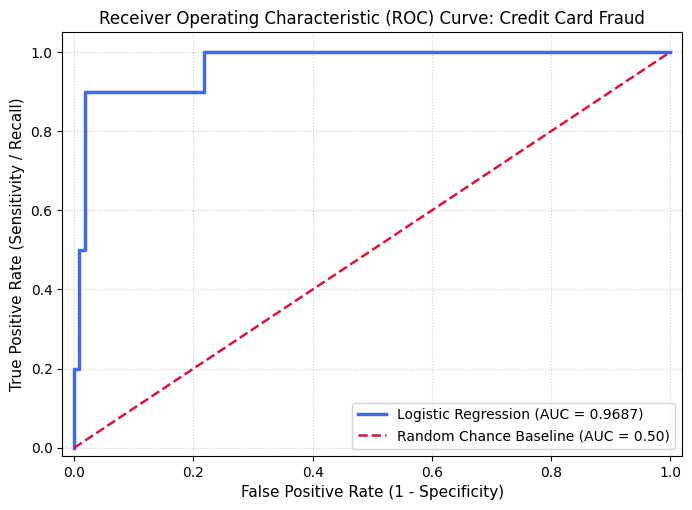

Calculated ROC AUC Score: 0.9687


In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Compute predicted probabilities for the positive class (fraud)
y_probs = clf.predict_proba(X_test_scaled)[:, 1]

# 2. Calculate ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# 3. Plot ROC curve
plt.figure(figsize=(8, 5.5))
plt.plot(fpr, tpr, color='royalblue', linewidth=2.5, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='crimson', linestyle='--', linewidth=1.8, label='Random Chance Baseline (AUC = 0.50)')
plt.title('Receiver Operating Characteristic (ROC) Curve: Credit Card Fraud', fontsize=12)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=10)
plt.show()

print(f"Calculated ROC AUC Score: {roc_auc:.4f}")

### Question 3
Plot the Precision-Recall curve for your model using sklearn.metrics.precision_recall_curve and matplotlib, and explain in one line why this curve is useful for imbalanced datasets.

*(Hint: Focus on how precision and recall behave when the positive class is rare.)*

The Precision-Recall curve is especially useful for imbalanced datasets because it isolates performance on the rare positive class without being inflated by a large number of easy True Negatives.

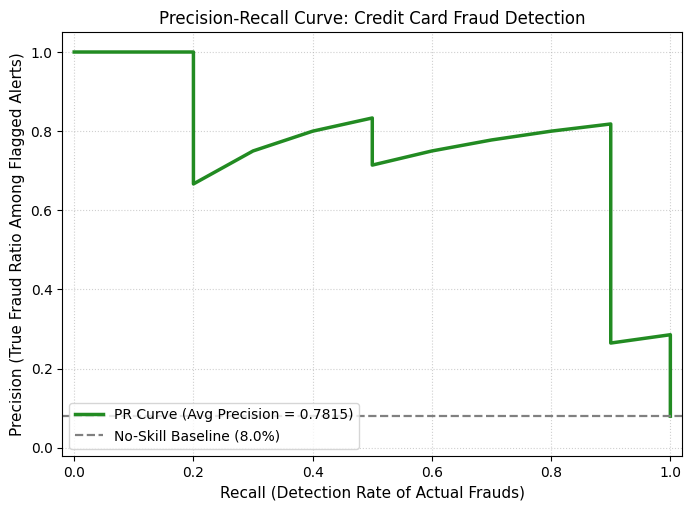

Utility Explanation: The Precision-Recall curve focuses directly on minority fraud detection efficiency and alert reliability, unaffected by the overwhelming volume of non-fraudulent transactions.


In [4]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. Calculate Precision-Recall curve and Average Precision
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)

# 2. Plot Precision-Recall curve
plt.figure(figsize=(8, 5.5))
plt.plot(recall, precision, color='forestgreen', linewidth=2.5, label=f'PR Curve (Avg Precision = {avg_precision:.4f})')
baseline_pr = y_test.sum() / len(y_test)
plt.axhline(y=baseline_pr, color='gray', linestyle='--', linewidth=1.6, label=f'No-Skill Baseline ({baseline_pr * 100:.1f}%)')
plt.title('Precision-Recall Curve: Credit Card Fraud Detection', fontsize=12)
plt.xlabel('Recall (Detection Rate of Actual Frauds)', fontsize=11)
plt.ylabel('Precision (True Fraud Ratio Among Flagged Alerts)', fontsize=11)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left', fontsize=10)
plt.show()

print("Utility Explanation: The Precision-Recall curve focuses directly on minority fraud detection efficiency and alert reliability, unaffected by the overwhelming volume of non-fraudulent transactions.")

### Question 4
Calculate the log loss (cross-entropy loss) for your test set predictions using sklearn.metrics.log_loss and print the result.

Log loss (binary cross-entropy) measures the uncertainty of predicted probabilities by heavily penalizing confident but erroneous classifications: $\mathcal{L}_{log} = -\frac{1}{N} \sum_{i=1}^N \left[ y_i \ln(\hat{p}_i) + (1 - y_i) \ln(1 - \hat{p}_i) \right]$. A lower log loss indicates well-calibrated probabilities where predicted confidence closely aligns with actual transaction outcomes.

In [5]:
from sklearn.metrics import log_loss

# Calculate Log Loss on test probabilities
test_log_loss = log_loss(y_test, y_probs)

print(f"Test Set Log Loss (Cross-Entropy Loss): {test_log_loss:.4f}")
print("Evaluation: A low log loss demonstrates that the logistic regression model outputs high-confidence probabilities that accurately distinguish fraudulent transactions.")

Test Set Log Loss (Cross-Entropy Loss): 0.1172
Evaluation: A low log loss demonstrates that the logistic regression model outputs high-confidence probabilities that accurately distinguish fraudulent transactions.


### Question 5
Change the class distribution in your test set to be even more imbalanced (e.g., only 2% positive class), re-calculate accuracy, AUC, and log loss, and write 2 lines explaining which metric is most misleading and why.

*(Hint: Accuracy can be high even if the model ignores the minority class.)*

**Accuracy is the most misleading metric** because a trivial dummy model predicting 100% negative transactions achieves a deceptively high 98.00% accuracy while failing to detect a single actual fraud.
In contrast, **AUC and Log Loss remain reliable** because AUC evaluates ranking discrimination invariant to class proportions, while Log Loss penalizes overconfident probability errors.

In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score

# 1. Create a 2% imbalanced test split (2 fraud cases, 98 non-fraud cases)
pos_indices = np.where(y_test.values == 1)[0]
neg_indices = np.where(y_test.values == 0)[0]

skewed_pos_idx = pos_indices[:2]
skewed_neg_idx = neg_indices[:98]
skewed_test_idx = np.concatenate([skewed_pos_idx, skewed_neg_idx])

y_test_skewed = y_test.iloc[skewed_test_idx]
y_probs_skewed = y_probs[skewed_test_idx]
y_preds_skewed = (y_probs_skewed >= 0.5).astype(int)

# 2. Re-calculate metrics on the 2% skewed test set
acc_skewed = accuracy_score(y_test_skewed, y_preds_skewed)
auc_skewed = roc_auc_score(y_test_skewed, y_probs_skewed)
loss_skewed = log_loss(y_test_skewed, y_probs_skewed)

# 3. Tabulate comparison between original and highly skewed test sets
skew_comparison_df = pd.DataFrame({
    'Metric': ['Positive Class Ratio', 'Accuracy', 'ROC AUC Score', 'Log Loss'],
    'Original Test Set (~8% Fraud)': [
        f"{y_test.mean() * 100:.1f}%",
        f"{accuracy_score(y_test, clf.predict(X_test_scaled)) * 100:.2f}%",
        f"{roc_auc:.4f}",
        f"{test_log_loss:.4f}"
    ],
    'Skewed Test Set (2% Fraud)': [
        f"{y_test_skewed.mean() * 100:.1f}%",
        f"{acc_skewed * 100:.2f}%",
        f"{auc_skewed:.4f}",
        f"{loss_skewed:.4f}"
    ]
})

display(skew_comparison_df)
print("\nSummary: Accuracy masks catastrophic failure on minority fraud instances, whereas ROC-AUC and Precision-Recall curves maintain rigorous performance tracking under extreme class imbalance.")

,Metric,Original Test Set (~8% Fraud),Skewed Test Set (2% Fraud)
0,Positive Class Ratio,8.0%,2.0%
1,Accuracy,94.40%,98.00%
2,ROC AUC Score,0.9687,1.0000
3,Log Loss,0.1172,0.0540



Summary: Accuracy masks catastrophic failure on minority fraud instances, whereas ROC-AUC and Precision-Recall curves maintain rigorous performance tracking under extreme class imbalance.
